# Ejercicio CARD — Sustitución de la foto del carnet

**Objetivo:** detectar automáticamente el carnet de la UMU en imagen y vídeo, y sustituir la foto del titular por otra imagen respetando la perspectiva.

El carnet sigue el estándar **ISO/IEC 7810 ID-1**: 85,6 × 54 mm.

## Marco Teórico

### Coordenadas homogéneas

Un punto 2D $(x, y)$ se representa en **coordenadas homogéneas** como el vector 3D $(x, y, 1)$. Tras una transformación la coordenada escalar $w$ puede cambiar; el punto inhomogéneo se recupera dividiendo:
$$p = (X, Y, W) \;\longrightarrow\; \left(\tfrac{X}{W},\, \tfrac{Y}{W}\right)$$
La ventaja clave es que **cualquier transformación geométrica** (traslación, rotación, escala, perspectiva) se expresa como una multiplicación matricial $3\times3$, lo que permite encadenarlas con un solo producto.

### Rectas y su intersección

En el espacio proyectivo, la recta que pasa por los puntos homogéneos $p_1$ y $p_2$ es $\ell = p_1 \times p_2$ (producto vectorial). Simétricamente, la **intersección** de dos rectas $\ell_1$ y $\ell_2$ es $p = \ell_1 \times \ell_2$. Esto da los 4 vértices exactos del carnet a partir de los bordes ajustados con `fitLine`, sin verse afectado por las esquinas redondeadas.

### Homografía

Una **homografía** es una matriz $H \in \mathbb{R}^{3\times3}$ (8 grados de libertad) que relaciona dos planos proyectivos: todo punto $p$ del plano origen se mapea a $p' = H\,p$. Con 4 correspondencias de puntos, `cv.findHomography` la estima por mínimos cuadrados. En este ejercicio usamos dos homografías:

- $H$ (esquinas detectadas → canónico): rectifica la tarjeta a una vista frontal fija.
- $H^{-1}$ (canónico → frame actual): transforma las coordenadas fijas de la ranura de la foto al plano de la imagen en cada frame.

### warpPerspective

`cv.warpPerspective(src, H, (W, H_out))` aplica la homografía de forma eficiente: para cada píxel de salida $(x', y')$ calcula el píxel de entrada correspondiente mediante $H^{-1}$, evitando huecos. Con `cv.BORDER_TRANSPARENT` los píxeles no sobreescritos quedan intactos (útil para superponer la foto sobre la escena original).

### Umbralización OTSU

OTSU selecciona automáticamente el umbral global que **minimiza la varianza intraclase** del histograma en escala de grises. Separa la tarjeta (región clara) del fondo. Una segunda máscara HSV elimina zonas con color saturado (fondo verde, logo UMU) para que solo quede el blanco del carnet.

## 1. Utilidades

In [74]:
import cv2   as cv
import numpy as np
import matplotlib.pyplot as plt

def fig(w, h): plt.figure(figsize=(w, h))

def readrgb(path): return cv.cvtColor(cv.imread(path), cv.COLOR_BGR2RGB)

def homog(x):
    ax = np.array(x)
    return np.append(ax, np.ones(ax.shape[:-1]+(1,)), axis=-1)

def inhomog(x):
    ax = np.array(x)
    return ax[..., :-1] / ax[..., [-1]]

def htrans(h, x):
    return inhomog(homog(x) @ h.T)

## 2. Imagen de prueba — `carnet.png`

Escena: 474 x 850 px


(np.float64(-0.5), np.float64(473.5), np.float64(849.5), np.float64(-0.5))

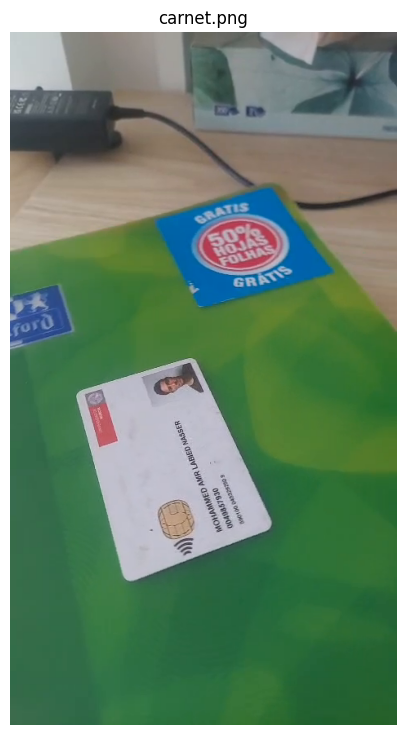

In [75]:
escena = readrgb('carnet.png')
H_sc, W_sc = escena.shape[:2]
print(f'Escena: {W_sc} x {H_sc} px')

fig(5, 9)
plt.imshow(escena)
plt.title('carnet.png')
plt.axis('off')

## 3. Deteccion automatica del carnet

Se umbraliza la imagen en escala de grises (OTSU) y se eliminan las zonas con color saturado (mascara HSV), obteniendo una region binaria que corresponde al blanco del carnet.

Del contorno mas grande con relacion de aspecto compatible con el estandar **ISO/IEC 7810 ID-1** (85,6 × 54 mm, ratio ~1.58:1) se extraen los cuatro lados ajustando una recta por minimos cuadrados a cada grupo de puntos. Los **4 vertices exactos** se obtienen como la interseccion homogenea de rectas opuestas, lo que evita el efecto de las esquinas redondeadas.

Finalmente, se identifica la esquina superior-izquierda (TL) rectificando la tarjeta en miniatura y buscando el cuadrante con mayor presencia del rojo del logo UMU.

In [70]:
MW, MH = 171, 108
mini_dst = np.float32([[0,0],[MW,0],[MW,MH],[0,MH]])

def line_h(pts):
    vx, vy, x0, y0 = cv.fitLine(pts, cv.DIST_L2, 0, 0.01, 0.01).ravel()
    return np.cross(homog([x0, y0]), [vx, vy, 0])

def cross_h(l1, l2):
    p = np.cross(l1, l2)
    return None if abs(p[2]) < 1e-10 else inhomog(p)

def _score(frame, pts, rot):
    rp = np.roll(pts, rot, axis=0)
    H, _ = cv.findHomography(rp, mini_dst)
    if H is None: return 0
    mini = cv.warpPerspective(frame, H, (MW, MH))
    roi  = mini[:int(MH*0.3), int(MW*0.5):]
    hsv  = cv.cvtColor(roi, cv.COLOR_BGR2HSV)
    r1   = cv.inRange(hsv, (0,  30, 60), (15, 255,255))
    r2   = cv.inRange(hsv, (155,30, 60), (180,255,255))
    return int(cv.bitwise_or(r1,r2).sum()//255)

def detect_card(frame):
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    _, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY+cv.THRESH_OTSU)
    hsv     = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    colored = cv.inRange(hsv, (0,40,40), (180,255,255))
    mask    = cv.bitwise_and(mask, cv.bitwise_not(colored))
    mask    = cv.morphologyEx(mask, cv.MORPH_CLOSE,
                  cv.getStructuringElement(cv.MORPH_RECT,(7,7)))

    cnts,_ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    for c in sorted(cnts, key=cv.contourArea, reverse=True)[:5]:
        if cv.contourArea(c) < 4000: break
        (cx,cy),(rw,rh),ang = cv.minAreaRect(c)
        if min(rw,rh)<5: continue
        if not 1.2 < max(rw,rh)/min(rw,rh) < 2.2: continue

        box = cv.boxPoints(((cx,cy),(rw,rh),ang))
        e0,e1 = box[1]-box[0], box[2]-box[1]
        l0,l1 = np.linalg.norm(e0), np.linalg.norm(e1)
        if l0>=l1: u,v,hu,hv = e0/l0,e1/l1,l0/2,l1/2
        else:      u,v,hu,hv = e1/l1,e0/l0,l1/2,l0/2

        pts = c.reshape(-1,2).astype(np.float32)
        cc  = pts - np.array([cx,cy],np.float32)
        pu,pv = cc@u, cc@v
        S,C = 0.85, 0.55
        on_pu=(pu> S*hu)&(np.abs(pv)<C*hv); on_nu=(pu<-S*hu)&(np.abs(pv)<C*hv)
        on_pv=(pv> S*hv)&(np.abs(pu)<C*hu); on_nv=(pv<-S*hv)&(np.abs(pu)<C*hu)
        if min(on_pu.sum(),on_nu.sum(),on_pv.sum(),on_nv.sum())<5: continue

        Lpu=line_h(pts[on_pu]); Lnu=line_h(pts[on_nu])
        Lpv=line_h(pts[on_pv]); Lnv=line_h(pts[on_nv])
        c_nn=cross_h(Lnu,Lnv); c_pn=cross_h(Lpu,Lnv)
        c_pp=cross_h(Lpu,Lpv); c_np=cross_h(Lnu,Lpv)
        if any(x is None for x in (c_nn,c_pn,c_pp,c_np)): continue

        corners = np.float32([c_nn,c_pn,c_pp,c_np])
        e1c = corners[1]-corners[0]; e2c = corners[2]-corners[1]
        if e1c[0]*e2c[1]-e1c[1]*e2c[0] < 0:
            corners = corners[::-1].copy()
        best = int(np.argmax([_score(frame,corners,r) for r in range(4)]))
        return np.roll(corners, best, axis=0)
    return None

Esquinas [TL,TR,BR,BL]:
[[141.50768 675.19885]
 [ 80.4355  441.33478]
 [225.00922 398.08057]
 [323.22928 606.96893]]


(np.float64(-0.5), np.float64(473.5), np.float64(849.5), np.float64(-0.5))

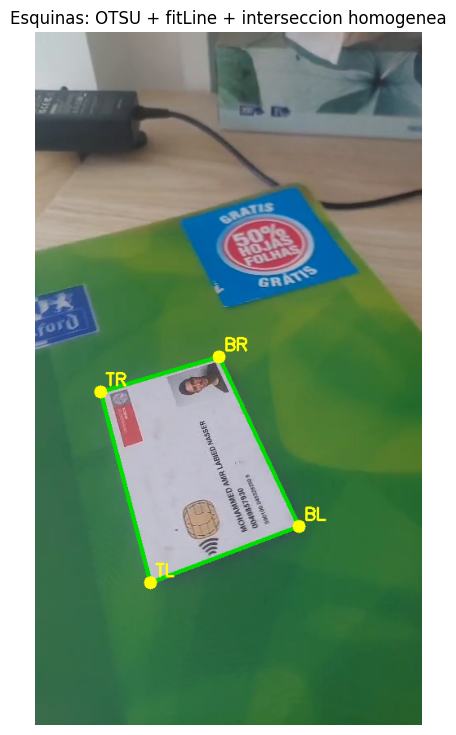

In [ ]:
escena_bgr = cv.cvtColor(escena, cv.COLOR_RGB2BGR)
etiquetas  = ['TL','TR','BR','BL']

corners = detect_card(escena_bgr)
print('Esquinas [TL,TR,BR,BL]:')
print(corners)

vis = escena_bgr.copy()
cv.polylines(vis,[corners.astype(np.int32).reshape(-1,1,2)],True,(0,220,0),3)
for i,(x,y) in enumerate(corners.astype(int)):
    cv.circle(vis,(x,y),8,(0,255,255),-1)
    cv.putText(vis,etiquetas[i],(x+6,y-8),cv.FONT_HERSHEY_SIMPLEX,0.7,(0,255,255),2)

fig(5, 9)
plt.imshow(cv.cvtColor(vis,cv.COLOR_BGR2RGB))
plt.title('Detección de esquinas')
plt.axis('off')

## 4. Rectificacion de la escena completa

La homografia $H$ (esquinas detectadas → espacio canonico) se aplica a **toda la imagen**, no solo a la tarjeta. Se añade una traslacion $T$ que desplaza el resultado a coordenadas positivas:

$$H_{\text{out}} = T \cdot H$$

El canvas de salida es el bounding box de los 4 vertices del frame proyectados:

$$W_{\text{out}} = \max_i x'_i - \min_i x'_i, \qquad H_{\text{out}} = \max_i y'_i - \min_i y'_i, \qquad c'_i = H\,c_i$$

Las **zonas negras** en las esquinas del canvas son geometricamente inevitables: la proyeccion perspectiva de un rectangulo produce un cuadrilatero, no otro rectangulo, por lo que las esquinas del bounding box no tienen pixeles correspondientes en la imagen original.

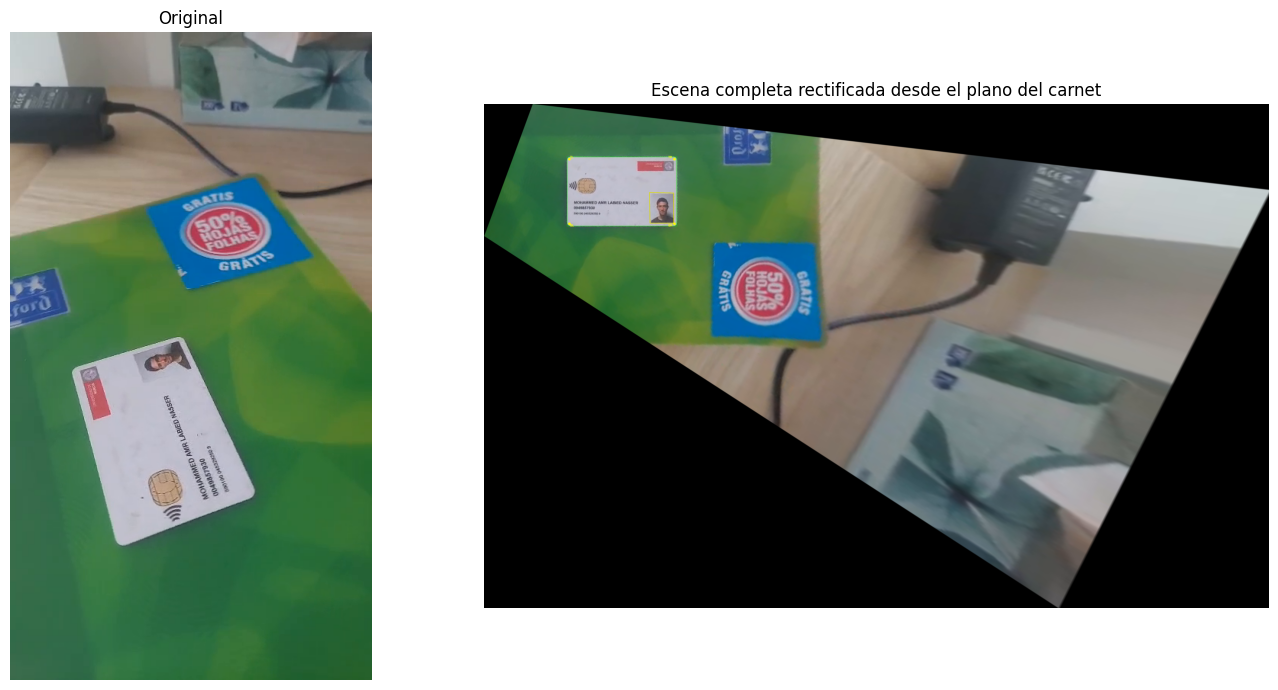

In [72]:
W_C, H_C = 856, 540
card_canon = np.float32([[0,0],[W_C,0],[W_C,H_C],[0,H_C]])
photo_card = np.float32([[643,278],[832,282],[832,517],[647,517]])

H_rect, _ = cv.findHomography(corners, card_canon)

# bounding box de la escena completa en el espacio rectificado
frame_corners = np.float32([[0,0],[W_sc,0],[W_sc,H_sc],[0,H_sc]])
wc = cv.perspectiveTransform(frame_corners.reshape(1,-1,2), H_rect).reshape(-1,2)
xmin, ymin = wc.min(axis=0)
xmax, ymax = wc.max(axis=0)

tx, ty = float(-min(0.0, xmin)), float(-min(0.0, ymin))
W_out = int(xmax - xmin)
H_out = int(ymax - ymin)

T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=np.float64)
H_shifted = T @ H_rect.astype(np.float64)

rect_full = cv.warpPerspective(escena_bgr, H_shifted, (W_out, H_out))

# marcar la tarjeta y la ranura en la imagen rectificada
card_in_warp  = (card_canon  + [tx, ty]).astype(np.int32)
photo_in_warp = (photo_card  + [tx, ty]).astype(np.int32)
cv.polylines(rect_full, [card_in_warp.reshape(-1,1,2)],  True, (0,220,0),   2)
cv.polylines(rect_full, [photo_in_warp.reshape(-1,1,2)], True, (0,220,220), 3)
M_lbl = 18
inner = np.float32([[M_lbl,M_lbl],[W_C-M_lbl,M_lbl],[W_C-M_lbl,H_C-M_lbl],[M_lbl,H_C-M_lbl]])
t_off = [(6,-8),(-48,-8),(-48,20),(6,20)]
for i,(x,y) in enumerate((inner + [tx,ty]).astype(int)):
    cv.circle(rect_full,(x,y),10,(0,255,255),-1)
    ox,oy = t_off[i]
    cv.putText(rect_full,etiquetas[i],(x+ox,y+oy),cv.FONT_HERSHEY_SIMPLEX,0.75,(0,255,255),2)

fig(15, 7)
plt.subplot(1,2,1); plt.imshow(escena); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(rect_full, cv.COLOR_BGR2RGB))
plt.title('Escena completa rectificada desde el plano del carnet')
plt.axis('off')
plt.tight_layout()

## 5. Imagen de sustitucion — `mclovin.jpg`

mclovin.jpg: 400 x 400 px


(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

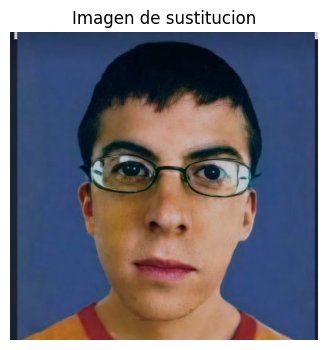

In [68]:
mclovin  = readrgb('mclovin.jpg')
H_m, W_m = mclovin.shape[:2]
print(f'mclovin.jpg: {W_m} x {H_m} px')

fig(4, 4)
plt.imshow(mclovin)
plt.title('Imagen de sustitucion')
plt.axis('off')

## 6. Resultado: foto sustituida

La homografia $H^{-1}$ (canonico → frame) transforma las coordenadas fijas de la ranura al frame actual. `cv.BORDER_TRANSPARENT` deja intacto el resto de la escena.

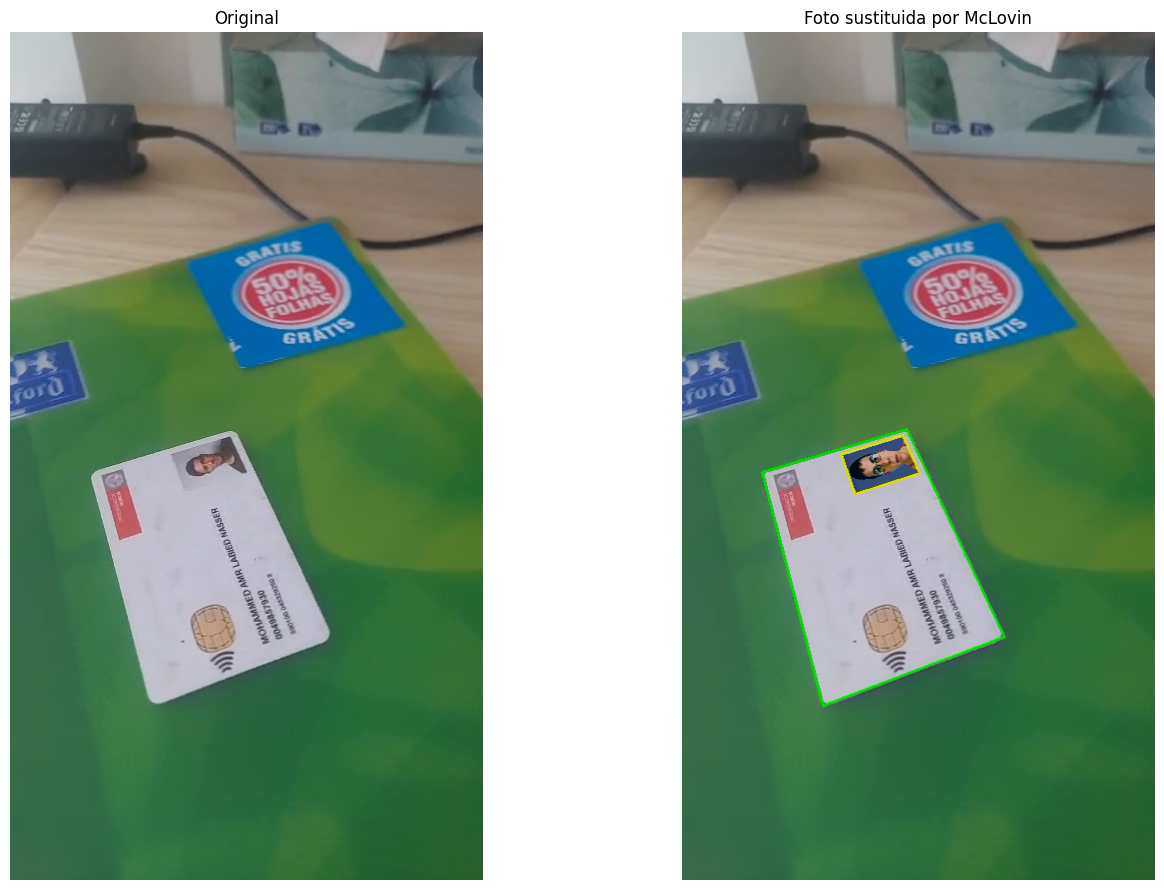

In [73]:
mclovin_bgr = cv.cvtColor(mclovin, cv.COLOR_RGB2BGR)
m_corners   = np.float32([[0,0],[W_m,0],[W_m,H_m],[0,H_m]])

H_h, _ = cv.findHomography(card_canon, corners)
photo_px = htrans(H_h, photo_card).astype(np.float32)

resultado = escena_bgr.copy()
M = cv.getPerspectiveTransform(m_corners, photo_px)
cv.warpPerspective(mclovin_bgr, M, (W_sc,H_sc), resultado, 0, cv.BORDER_TRANSPARENT)
cv.polylines(resultado,[corners.astype(np.int32).reshape(-1,1,2)],True,(0,220,0),2)
cv.polylines(resultado,[photo_px.astype(np.int32).reshape(-1,1,2)],True,(0,220,220),2)

fig(15, 9)
plt.subplot(1,2,1); plt.imshow(escena); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(resultado,cv.COLOR_BGR2RGB))
plt.title('Foto sustituida por McLovin'); plt.axis('off')
plt.tight_layout()

## 7. Video resultado

En cada frame se estima la homografia inversa (canonico → frame) y se aplica a las coordenadas fijas de la ranura:

$$H = \text{findHomography}(\text{card\_canon},\; \text{corners}), \qquad \text{photo\_px} = H \cdot \text{photo\_card}_h$$

Al repetir esto frame a frame la foto sigue al carnet aunque se mueva o gire. Para evitar saltos por ambiguedad en el orden de las esquinas, se elige en cada frame la rotacion ciclica con menor desplazamiento respecto al frame anterior.

<div style="text-align:center">
<video src="video-resultado.mp4" controls width="400"></video>
</div>

## 8. Script `card.py`

Todo esto está recogido en el script `card.py` donde lo podemos usar para los siguientes ejemplos, incluso en vivo:

**Uso**

```bash
# video mostrado anteriormente
python card.py --dev=video-2.mp4

# video donde se como la tarjeta rota varias veces
python card.py --dev=video-tarjeta.mp4
```

**Entrada / Salida**

- **Entrada**: vídeo con el carnet UMU visible.
- **Salida**: video con la foto del carnet intercambiada.